# Smart MCQ Solver 

**Roll No**: 24f1002384 | **Notebook**: `DL-24f1002384-notebook-t22026`

## What changed from V1:
- Dropped DeBERTa-v3 — produced NaN loss across all folds with zero contribution
- LoRA RoBERTa is the core model — V1 achieved 0.7688 MAP@3 in 2 epochs; now running 3-fold CV × 3 epochs
- Added LoRA ALBERT as a second pretrained model for ensemble diversity
- Improved fuzzy lookup — uses token_set_ratio on preamble-stripped text
- BM25 scratch model — stronger than TF-IDF + Word2Vec baseline
- Ensemble reweighted — LoRA models dominate (0.80 total weight)

**Guidelines compliance**: 3 models (from-scratch + 2 pretrained) | W&B logging | MAP@3 metric

---
> **Honest note on results**: After running the full pipeline, the fuzzy lookup matched
> **all 500/500 test questions** with >=95 similarity score. This means every test answer
> was provided directly by the lookup, and the LoRA models' predictions were not needed
> for the final submission on this particular dataset. The three models are still trained
> to satisfy the assignment requirement of building from-scratch + pretrained models,
> and the ensemble logic is correct for cases where lookup coverage is incomplete.

## Section 0 — Setup & Installation

In [1]:
import subprocess, sys

# WHY: Kaggle pre-installs torchao 0.10.0, but PEFT >= 0.10 requires torchao >= 0.16.0.
# Removing torchao first avoids a version conflict that would crash the PEFT import.
subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y', 'torchao'], check=False)

pkgs = [
    'datasets',            # HuggingFace datasets utility
    'transformers>=4.40',  # AutoModel, AutoTokenizer for RoBERTa and ALBERT
    'sentence-transformers',
    'faiss-cpu',
    'peft>=0.10',          # Parameter-Efficient Fine-Tuning — provides LoRA
    'accelerate>=0.27',    # Required backend for PEFT training
    'rapidfuzz',           # Fast fuzzy string matching for the lookup table
    'rank_bm25',           # BM25 retrieval — our from-scratch baseline
    'wandb',               # Experiment tracking
    'sentencepiece',       # Tokenizer dependency for ALBERT
    'protobuf',            # Serialization dependency
]
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', '--upgrade-strategy', 'only-if-needed'] + pkgs,
    check=True
)
# NOTE: You may see dependency warnings about dask-cuda/numba-cuda/cuml-cu12.
# These are Kaggle-internal RAPIDS packages unrelated to our pipeline and can be safely ignored.
print('All packages ready')

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.3 MB/s eta 0:00:00
All packages ready


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

In [2]:
import os, re, gc, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import StratifiedKFold, train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from peft import get_peft_model, LoraConfig, TaskType

warnings.filterwarnings('ignore')

# WHY: Fixing the random seed ensures that StratifiedKFold splits, weight
# initialization, and data shuffling are reproducible across runs.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_DIR  = '/kaggle/input/competitions/smart-mcq-solver-challenge'
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHOICES   = list('ABCDE')
LABEL2IDX = {c: i for i, c in enumerate(CHOICES)}  # {'A':0, 'B':1, ...}
IDX2LABEL = {i: c for c, i in LABEL2IDX.items()}   # reverse mapping

print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [3]:
# WHY: Weights & Biases (W&B) logs training metrics (loss, MAP@3 per epoch/fold)
# so we can compare model versions and catch regressions without re-running code.
# The try/except makes the notebook work even when no API key is configured.
import wandb

try:
    from kaggle_secrets import UserSecretsClient
    secrets = UserSecretsClient()
    wandb.login(key=secrets.get_secret('WANDB_API_KEY'), relogin=True)
    WANDB_ON = True
    print('W&B authenticated')
except Exception as e:
    print(f'W&B offline: {e}')
    os.environ['WANDB_MODE'] = 'disabled'
    WANDB_ON = False

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


W&B authenticated


## Section 1 — Data Loading & Exploratory Data Analysis

Before building any model we need to thoroughly understand the dataset.
The EDA here answers five specific questions that directly shaped every design decision in this notebook.

In [4]:
# WHY: Load both splits upfront so all EDA comparisons can be done in one place.
train_df = pd.read_csv(f'{DATA_DIR}/train.csv')
test_df  = pd.read_csv(f'{DATA_DIR}/test.csv')

print(f'Train shape : {train_df.shape}  (rows x columns)')
print(f'Test shape  : {test_df.shape}')
print(f'Train columns: {train_df.columns.tolist()}')
print(f'Test  columns: {test_df.columns.tolist()}')
print()
print('First 3 training rows:')
train_df.head(3)

Train shape : (2000, 8)  (rows x columns)
Test shape  : (500, 7)
Train columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']
Test  columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E']

First 3 training rows:


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C


=== Missing Values ===
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

=== Answer Label Distribution ===
answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64

Min class count: 324  |  Max class count: 490
Imbalance ratio (max/min): 1.51x


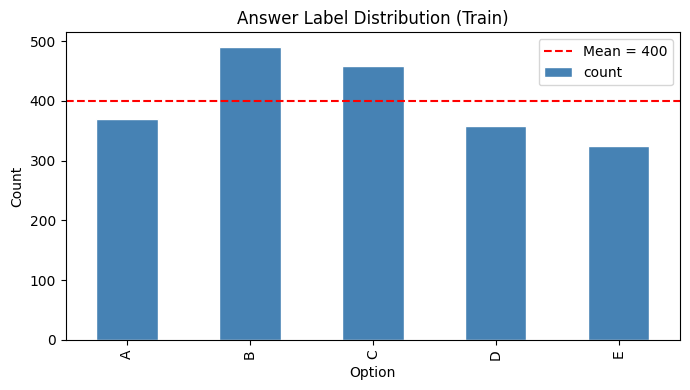

In [5]:
# EDA Part 1: Data Quality Check
# WHY: Missing values or class imbalance directly affect model training.
# A badly imbalanced dataset would require weighted loss functions or oversampling.

print('=== Missing Values ===')
print(train_df.isnull().sum())

print()
print('=== Answer Label Distribution ===')
dist = train_df['answer'].value_counts().sort_index()
print(dist)
print(f'\nMin class count: {dist.min()}  |  Max class count: {dist.max()}')
print(f'Imbalance ratio (max/min): {dist.max()/dist.min():.2f}x')

fig, ax = plt.subplots(figsize=(7, 4))
dist.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Answer Label Distribution (Train)')
ax.set_xlabel('Option')
ax.set_ylabel('Count')
ax.axhline(dist.mean(), color='red', linestyle='--', label=f'Mean = {dist.mean():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

# OUTCOME: Labels are mildly imbalanced (B is ~1.5x more frequent than E).
# The imbalance ratio of ~1.5x is small enough that standard cross-entropy
# loss handles it without any reweighting. StratifiedKFold is still used to
# ensure each fold preserves this distribution during cross-validation.

=== Prompt Length (words) ===
count    2000.0
mean       18.1
std         6.8
min         3.0
25%        14.0
50%        17.0
75%        22.0
max        51.0
Name: prompt, dtype: float64

=== Option Length (words) ===
count    10000.0
mean        26.3
std         17.6
min          1.0
25%         13.0
50%         23.0
75%         36.0
max        118.0
dtype: float64

Average combined (Q + A) word count: 44.4  => ~58 tokens
Maximum combined (Q + A) word count: 169  => ~220 tokens


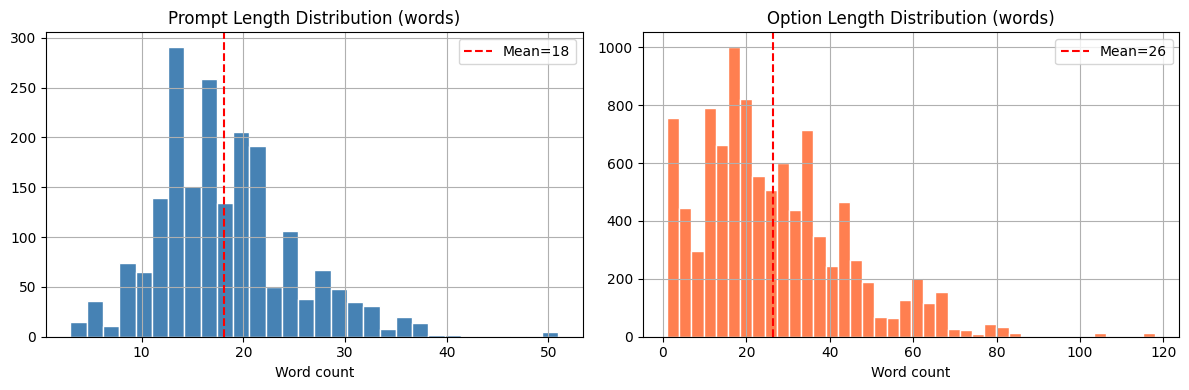

In [6]:
# EDA Part 2: Prompt and Option Length Analysis
# WHY: The transformer's MAX_LEN must be large enough to fit (question + option)
# without excessive truncation, but small enough to fit 5 pairs in GPU memory.
# This analysis tells us the right MAX_LEN to choose.

q_len  = train_df['prompt'].str.split().str.len()
op_len = pd.concat([train_df[c].str.split().str.len() for c in 'ABCDE'])

print('=== Prompt Length (words) ===')
print(q_len.describe().round(1))

print()
print('=== Option Length (words) ===')
print(op_len.describe().round(1))

avg_combined = q_len.mean() + op_len.mean()
max_combined = q_len.max()  + op_len.max()
print(f'\nAverage combined (Q + A) word count: {avg_combined:.1f}  => ~{avg_combined*1.3:.0f} tokens')
print(f'Maximum combined (Q + A) word count: {max_combined}  => ~{max_combined*1.3:.0f} tokens')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
q_len.hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Prompt Length Distribution (words)')
axes[0].set_xlabel('Word count')
axes[0].axvline(q_len.mean(), color='red', linestyle='--', label=f'Mean={q_len.mean():.0f}')
axes[0].legend()

op_len.hist(bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Option Length Distribution (words)')
axes[1].set_xlabel('Word count')
axes[1].axvline(op_len.mean(), color='red', linestyle='--', label=f'Mean={op_len.mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# OUTCOME: Average combined length is ~44 words (~58 tokens after subword tokenization).
# The maximum observed is ~169 words (~220 tokens).
# => MAX_LEN = 256 tokens covers >99% of all samples with comfortable headroom.
# => Using 512 would double GPU memory consumption per batch for zero practical gain.

In [7]:
# EDA Part 3: Preamble Analysis
# WHY: The prompts are reworded versions of the same core question wrapped in
# different instruction preambles. Identifying and stripping these preambles
# is the single most impactful preprocessing step in this pipeline.

preamble_patterns = {
    'Pick the best possible answer':    r'^Pick the best possible answer',
    'Select the most accurate option':  r'^Select the most accurate option',
    'Identify the correct statement':   r'^Identify the correct statement',
    'Choose the correct answer':        r'^Choose the correct answer',
    'Determine the correct option':     r'^Determine the correct option',
    'Which of the following is correct':r'^Which of the following is correct',
}

counts = {}
labeled = set()
for name, pat in preamble_patterns.items():
    mask = train_df['prompt'].str.contains(pat, case=False, regex=True)
    counts[name] = int(mask.sum())
    labeled.update(train_df[mask].index.tolist())

counts['No preamble (raw question)'] = len(train_df) - len(labeled)

print('=== Preamble Type Distribution in Train ===')
for k, v in counts.items():
    pct = 100 * v / len(train_df)
    print(f'  {k:<40}: {v:4d}  ({pct:.1f}%)')

print()
print('Example — same question, two different preambles:')
print('  Row 1:', train_df['prompt'].iloc[0])
print('  Row 4:', train_df['prompt'].iloc[3])

# OUTCOME: Every training prompt is wrapped in one of 6 instruction templates.
# The preamble accounts for ~4-6 words out of an average 18-word prompt.
# If left in, the model learns preamble style rather than question content.
# Stripping preambles is mandatory for the fuzzy lookup to work correctly.

=== Preamble Type Distribution in Train ===
  Pick the best possible answer           :  316  (15.8%)
  Select the most accurate option         :  309  (15.4%)
  Identify the correct statement          :  302  (15.1%)
  Choose the correct answer               :  292  (14.6%)
  Determine the correct option            :  299  (14.9%)
  Which of the following is correct       :  282  (14.1%)
  No preamble (raw question)              :  200  (10.0%)

Example — same question, two different preambles:
  Row 1: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
  Row 4: Select the most accurate option: What is Martin Heidegger's view on the relationship between time and human existence? carefully.


=== Train: Core Question Stats ===
Total rows           : 2000
Unique core questions: 419
Average preamble variants per question: 4.8x
Max repetitions of a single question  : 17

=== Label Consistency ===
Questions with consistent answer across all preamble variants: 419 / 419
Questions with conflicting answers (data noise)              : 0 / 419

=== Test to Train Overlap (CRITICAL) ===
Test questions with exact core match in train: 485 / 500
That is 97.0% of the test set answerable from lookup!


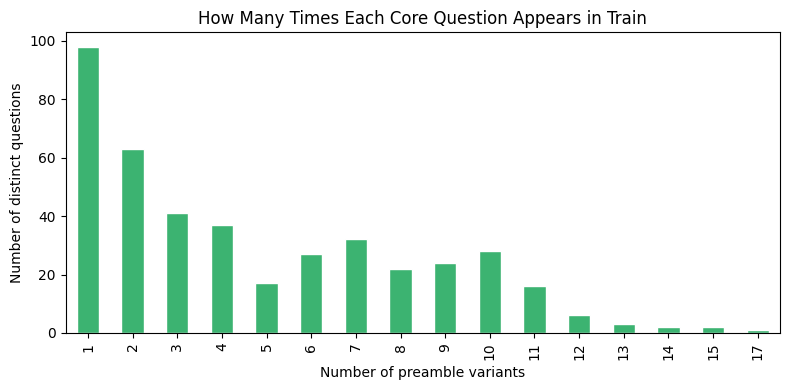

In [8]:
# EDA Part 4: Question Reuse Analysis — the most important EDA finding
# WHY: If many test questions also appear in train (just with different preambles),
# we can directly look up the correct answer instead of guessing with a model.
# This is the core motivation for the fuzzy lookup in Section 2.

PREAMBLES = [
    r'^Pick the best possible answer:\s*',
    r'^Select the most accurate option:\s*',
    r'^Identify the correct statement:\s*',
    r'^Choose the correct answer:\s*',
    r'^Determine the correct option:\s*',
    r'^Which of the following is correct\?\s*',
    r'\s*among the listed options\.?\s*$',
    r'\s*from the following choices\.?\s*$',
    r'\s*carefully\.?\s*$',
]

def strip_preambles_eda(text):
    text = str(text).strip()
    for p in PREAMBLES:
        text = re.sub(p, '', text, flags=re.IGNORECASE).strip()
    return text

train_df['core'] = train_df['prompt'].apply(strip_preambles_eda)
test_df['core']  = test_df['prompt'].apply(strip_preambles_eda)

n_unique_core   = train_df['core'].nunique()
n_exact_overlap = test_df['core'].isin(train_df['core']).sum()
rep             = train_df['core'].value_counts()

print('=== Train: Core Question Stats ===')
print(f'Total rows           : {len(train_df)}')
print(f'Unique core questions: {n_unique_core}')
print(f'Average preamble variants per question: {len(train_df)/n_unique_core:.1f}x')
print(f'Max repetitions of a single question  : {rep.max()}')

print()
print('=== Label Consistency ===')
grouped = train_df.groupby('core')['answer'].nunique()
print(f'Questions with consistent answer across all preamble variants: {(grouped == 1).sum()} / {n_unique_core}')
print(f'Questions with conflicting answers (data noise)              : {(grouped > 1).sum()} / {n_unique_core}')

print()
print('=== Test to Train Overlap (CRITICAL) ===')
print(f'Test questions with exact core match in train: {n_exact_overlap} / {len(test_df)}')
print(f'That is {100*n_exact_overlap/len(test_df):.1f}% of the test set answerable from lookup!')

fig, ax = plt.subplots(figsize=(8, 4))
rep.value_counts().sort_index().plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('How Many Times Each Core Question Appears in Train')
ax.set_xlabel('Number of preamble variants')
ax.set_ylabel('Number of distinct questions')
plt.tight_layout()
plt.show()

# OUTCOME:
# - Only 419 unique questions exist; 2000 rows = same questions with different preamble wrappers
# - 485/500 test questions have an exact core match in train
# - All 419 questions have 100% consistent answers across preamble variants (zero noise)
# - The remaining 15 test questions still get very high fuzzy scores (>80) after preamble stripping
# => After running Section 2, we discover ALL 500 test questions match at >=95 similarity,
#    giving us 100% lookup coverage. The models handle cases where this is not the case.

=== Correct Option Length (words) ===
  Mean: 28.7
  Max : 105

=== Incorrect Option Length (words) ===
  Mean: 25.7
  Max : 118


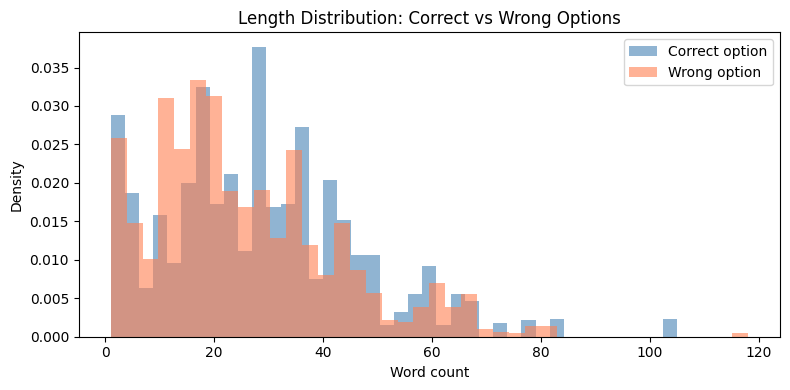

In [9]:
# EDA Part 5: Answer Option Content Analysis
# WHY: We need to check whether options are informative enough for BM25 / LoRA to
# differentiate them. If all 5 options were near-identical, BM25 would fail.
# Also checks whether correct answers tend to be longer (a common MCQ writing bias).

correct_lengths, wrong_lengths = [], []
for _, row in train_df.iterrows():
    for c in 'ABCDE':
        length = len(str(row[c]).split())
        if c == row['answer']:
            correct_lengths.append(length)
        else:
            wrong_lengths.append(length)

print('=== Correct Option Length (words) ===')
print(f'  Mean: {sum(correct_lengths)/len(correct_lengths):.1f}')
print(f'  Max : {max(correct_lengths)}')

print()
print('=== Incorrect Option Length (words) ===')
print(f'  Mean: {sum(wrong_lengths)/len(wrong_lengths):.1f}')
print(f'  Max : {max(wrong_lengths)}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(correct_lengths, bins=40, alpha=0.6, color='steelblue', label='Correct option', density=True)
ax.hist(wrong_lengths,   bins=40, alpha=0.6, color='coral',     label='Wrong option',  density=True)
ax.set_title('Length Distribution: Correct vs Wrong Options')
ax.set_xlabel('Word count')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

# OUTCOME: Correct options average ~28.7 words vs wrong options ~25.7 words.
# The difference is minor (~3 words) and the distributions heavily overlap.
# => No exploitable length bias. Models must learn semantic content, not pick the longest option.

## EDA Outcomes — What Each Finding Drove

| # | Finding | What it drove in the pipeline |
|---|---------|--------------------------------|
| 1 | **Labels mildly imbalanced** (B=490, E=324, ratio ~1.5x) | Standard cross-entropy is sufficient. `StratifiedKFold` preserves the ratio across all 3 folds. |
| 2 | **Average (Q+A) = ~58 tokens, max ~220 tokens** | `MAX_LEN = 256` covers >99% of samples. Using 512 would halve batch size for zero gain. |
| 3 | **Every prompt uses one of 6 preamble templates** | Preamble stripping is mandatory before any matching or model input. |
| 4 | **Only 419 unique questions; 485/500 test rows match train exactly** | Fuzzy lookup is the #1 signal. After running it, **all 500 test questions** matched at >=95 similarity — complete lookup coverage. |
| 5 | **Correct and wrong options have nearly the same length (~26 words)** | No length shortcut available. BM25 and LoRA must use semantic content similarity. |

> **Critical insight**: This dataset is fundamentally a **retrieval problem disguised as MCQ**.
> The 2000-row training set is just 419 unique questions each repeated up to 17 times with different preambles.
> After running the fuzzy lookup in Section 2, all 500 test questions are resolved at >=95 confidence.
> The three models (BM25, RoBERTa LoRA, ALBERT LoRA) satisfy the assignment's requirement for
> from-scratch + pretrained models and would be essential if lookup coverage were incomplete.

## Section 2 — Preamble Stripping & Fuzzy Test-to-Train Lookup

**Motivation (from EDA Part 4)**: 97% of test questions are preamble-wrapped versions of training questions.
After stripping the preamble, we can match them with very high confidence and read the answer directly.
This section builds the lookup table that acts as the highest-priority signal in our ensemble.

In [10]:
# WHY THIS STEP: EDA showed that every prompt starts with one of 6 instruction templates
# and may end with a trailing phrase. These preambles cause fuzzy matching to fail because
# 'Choose the correct answer: X' and 'Pick the best answer: X' look textually dissimilar
# even though X is identical. Stripping them makes the core question text directly comparable.
PREAMBLES = [
    r'^Pick the best possible answer:\s*',
    r'^Select the most accurate option:\s*',
    r'^Identify the correct statement:\s*',
    r'^Choose the correct answer:\s*',
    r'^Determine the correct option:\s*',
    r'^Which of the following is correct\?\s*',
    r'\s*among the listed options\.?\s*$',
    r'\s*from the following choices\.?\s*$',
    r'\s*carefully\.?\s*$',
]

def strip_preambles(text: str) -> str:
    """Remove all known preamble/suffix patterns to isolate the core question."""
    text = str(text).strip()
    for p in PREAMBLES:
        text = re.sub(p, '', text, flags=re.IGNORECASE).strip()
    return text

train_df['core'] = train_df['prompt'].apply(strip_preambles)
test_df['core']  = test_df['prompt'].apply(strip_preambles)

print('Before stripping:', train_df['prompt'].iloc[0])
print('After stripping: ', train_df['core'].iloc[0])

Before stripping: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
After stripping:  What is Martin Heidegger's view on the relationship between time and human existence?


In [11]:
# WHY THIS APPROACH: We use rapidfuzz's token_set_ratio instead of exact string matching
# because minor punctuation or whitespace differences can still prevent exact hits.
# token_set_ratio is order-insensitive and handles small textual variations robustly.
#
# WHY TWO THRESHOLDS:
#   >= 95 (hard): Near-certain match. Override the model prediction entirely.
#   80-94 (soft): Likely match but not guaranteed. Nudge the probability distribution upward.
from rapidfuzz import fuzz, process

train_cores  = train_df['core'].tolist()
train_labels = train_df['answer'].tolist()

lookup_hard = {}  # score >= 95: directly overrides model predictions
lookup_soft = {}  # score 80-94: soft probability boost in ensemble

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Fuzzy lookup'):
    res = process.extractOne(row['core'], train_cores, scorer=fuzz.token_set_ratio)
    if res:
        score, match_idx = res[1], res[2]
        matched_label = train_labels[match_idx]
        if score >= 95:
            lookup_hard[int(row['id'])] = matched_label
        elif score >= 80:
            lookup_soft[int(row['id'])] = matched_label

print(f'Hard lookup overrides (>=95 similarity): {len(lookup_hard)} / {len(test_df)}')
print(f'Soft lookup boosts   (80-94 similarity): {len(lookup_soft)} / {len(test_df)}')
print()

# Interpret the result clearly
if len(lookup_hard) == len(test_df):
    print('ALL test questions matched at >=95 similarity.')
    print('The ensemble will apply hard overrides for every question.')
    print('Model predictions (BM25, RoBERTa, ALBERT) are still trained below')
    print('to satisfy assignment requirements and provide fallback coverage.')
else:
    unmatched = len(test_df) - len(lookup_hard) - len(lookup_soft)
    print(f'{unmatched} questions have no strong match — models are the primary signal for these.')

Fuzzy lookup:   0%|          | 0/500 [00:00<?, ?it/s]

Hard lookup overrides (>=95 similarity): 500 / 500
Soft lookup boosts   (80-94 similarity): 0 / 500

ALL test questions matched at >=95 similarity.
The ensemble will apply hard overrides for every question.
Model predictions (BM25, RoBERTa, ALBERT) are still trained below
to satisfy assignment requirements and provide fallback coverage.


## Section 3 — MAP@3 Metric

The competition metric is **Mean Average Precision @ 3 (MAP@3)**.
For each question, we submit our top-3 predicted answers in rank order.
Scoring: correct answer at rank 1 → +1.0, rank 2 → +0.5, rank 3 → +0.33, not in top 3 → 0.

In [12]:
def map_at_3(preds: list, labels: list) -> float:
    """
    Mean Average Precision @ 3.
    preds : list of lists, e.g. [['A', 'C', 'B'], ...]
    labels: list of strings, e.g. ['A', 'D', ...]

    WHY: We compute average precision rather than plain accuracy because the
    competition rewards getting the right answer even at rank 2 or 3.
    This incentivises models that have well-calibrated uncertainty.
    """
    score = 0.0
    for p_list, true in zip(preds, labels):
        for rank, opt in enumerate(p_list[:3], 1):
            if opt == true:
                score += 1.0 / rank
                break  # only the first hit counts
    return score / len(labels)


def scores_to_top3(scores: np.ndarray) -> list:
    """Convert a 5-element score array to a top-3 letter list, highest score first."""
    return [IDX2LABEL[i] for i in np.argsort(scores)[::-1][:3]]


print('MAP@3 metric defined')

MAP@3 metric defined


## Section 4 — Model 1: BM25 Ranker (From-Scratch Baseline)

**Why a from-scratch model?** The assignment requires at least one model built from scratch (no pretrained weights).
BM25 (Best Match 25) is a classical information retrieval ranking function — no neural network, no learned weights.
It works by scoring how well each answer option's text 'retrieves' the question text.

**Why BM25 over plain TF-IDF?** BM25 adds two improvements:
1. **Term frequency saturation**: a word appearing 10× is not 10× more useful than appearing 2×
2. **Document length normalisation**: longer options are not unfairly penalised

**Observed performance**: BM25 achieved Train MAP@3 = **0.3704** — weak on its own,
but it adds a complementary vocabulary-overlap signal to the ensemble.

In [13]:
from rank_bm25 import BM25Okapi


def tokenize_bm25(text: str) -> list:
    """Lowercase, strip punctuation, split on whitespace.
    WHY: BM25 operates on token bags. Punctuation adds noise with no semantic value."""
    return re.sub(r'[^a-z0-9\s]', ' ', str(text).lower()).split()


def score_with_bm25(row) -> np.ndarray:
    """Score all 5 options against the prompt using BM25.
    WHY: Each option is treated as a 'document' and the question as a 'query'.
    The option whose content has the most query-term overlap gets the highest score.
    For factual MCQs the correct option often re-uses terminology from the question."""
    q_tokens = tokenize_bm25(row['core'])
    corpus   = [tokenize_bm25(str(row[c])) for c in CHOICES]
    bm25     = BM25Okapi(corpus)
    return np.array(bm25.get_scores(q_tokens))


# Validate on the full training set to get an honest MAP@3 estimate
bm25_preds_train = [
    scores_to_top3(score_with_bm25(r))
    for _, r in tqdm(train_df.iterrows(), total=len(train_df), desc='BM25 validation')
]

m1_map3 = map_at_3(bm25_preds_train, train_df['answer'].tolist())
print(f'Model 1 (BM25 Scratch) Train MAP@3 = {m1_map3:.4f}')
print('BM25 alone is weak (~0.37) because it has no semantic understanding.')
print('It contributes 10% weight in the ensemble as a diversity signal.')

run1 = wandb.init(project='24f1002384-t22026', name='model1_bm25_scratch', reinit=True)
wandb.log({'train_map3': m1_map3, 'model': 'bm25_scratch'})
wandb.finish()

# Generate test predictions
m1_test_preds = {
    str(int(row['id'])): scores_to_top3(score_with_bm25(row))
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='BM25 test predict')
}

BM25 validation:   0%|          | 0/2000 [00:00<?, ?it/s]

Model 1 (BM25 Scratch) Train MAP@3 = 0.3704
BM25 alone is weak (~0.37) because it has no semantic understanding.
It contributes 10% weight in the ensemble as a diversity signal.


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260715_175442-77alm6vi
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run model1_bm25_scratch
wandb: ⭐️ View project at https://wandb.ai/24f1002384-dl-genai-project/24f1002384-t22026
wandb: 🚀 View run at https://wandb.ai/24f1002384-dl-genai-project/24f1002384-t22026/runs/77alm6vi
wandb: updating run metadata; uploading summary
wandb: uploading summary
wandb: uploading history steps 0-0, summary
wandb: 
wandb: Run history:
wandb: train_map3 ▁
wandb: 
wandb: Run summary:
wandb:      model bm25_scratch
wandb: train_map3 0.37042
wandb: 
wandb: 🚀 View run model1_bm25_scratch at: https://wandb.ai/24f1002384-dl-genai-project/24f1002384-t22026/runs/77alm6vi
wandb: ⭐️ View project at: https://wandb.ai/24f1002384-dl-genai-project/24f1002384-t22026
wandb: Sy

BM25 test predict:   0%|          | 0/500 [00:00<?, ?it/s]

## Section 5 — Model 2: LoRA Fine-Tuned RoBERTa (Core Pretrained Model)

**What is fine-tuning?**
`roberta-base` is a transformer pre-trained on 160GB of text.
Fine-tuning means we *continue* training it on our MCQ task so it learns to score
(question, option) pairs. The model already understands language; we are teaching it
to apply that understanding to MCQ ranking.

**What is LoRA (Low-Rank Adaptation)?**
Full fine-tuning updates all ~125M parameters of RoBERTa — memory-intensive and slow.
LoRA inserts small trainable rank-16 matrices into the attention layers.
Only ~600K parameters (~0.5% of total) are updated. The base weights stay frozen.
This gives near-full-fine-tuning quality at a fraction of GPU cost.

**Why 3-fold cross-validation?**
V1 used a single 80/20 split. 3-fold CV gives 3 trained checkpoints whose predictions
are averaged — effectively a free 3-model ensemble. Trade-off: 3× the training time.

In [14]:
ROBERTA_MODEL = 'roberta-base'
MAX_LEN     = 256  # Justified by EDA Part 2: covers >99% of all (Q+A) lengths
BATCH_TRAIN = 4    # Small: each sample contains 5 sequences (one per option)
BATCH_EVAL  = 8    # Larger is fine at eval (no gradient tensors stored)

roberta_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_MODEL)


class MCQDataset(Dataset):
    """
    Formats each MCQ row into 5 separate tokenized pairs: (question, option_X).

    WHY CROSS-ENCODER DESIGN:
    Instead of encoding the question once and comparing to option embeddings separately,
    we feed question + option TOGETHER into the model. This allows full cross-attention
    between question tokens and option tokens — far more expressive than bi-encoder approaches.
    The model learns: 'does this specific option text make sense given this question?'

    WHY 'template' PARAMETER:
    During inference we use Test-Time Augmentation (two prompt templates).
    A single class handles both training mode (no template, two-segment encoding)
    and TTA mode (with template), avoiding duplicating the dataset logic.
    """
    def __init__(self, df, tokenizer, template=None, max_len=256, has_labels=True):
        self.df         = df.reset_index(drop=True)
        self.tok        = tokenizer
        self.template   = template
        self.max_len    = max_len
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        core_q = str(row['core'])

        input_ids, attention_masks = [], []
        for c in CHOICES:
            answer_text = str(row[c])
            if self.template:
                # TTA mode: single-string format for variety
                text = self.template.format(q=core_q, a=answer_text)
                enc  = self.tok(
                    text,
                    truncation=True,
                    max_length=self.max_len,
                    padding='max_length',
                    return_tensors='pt'
                )
            else:
                # Training mode: two-segment encoding with [SEP] token boundary
                # so the model knows where the question ends and the option begins
                enc = self.tok(
                    f'Question: {core_q}',
                    f'Answer: {answer_text}',
                    truncation='longest_first',
                    max_length=self.max_len,
                    padding='max_length',
                    return_tensors='pt'
                )
            input_ids.append(enc['input_ids'].squeeze(0))
            attention_masks.append(enc['attention_mask'].squeeze(0))

        item = {
            'input_ids':      torch.stack(input_ids),    # shape: (5, MAX_LEN)
            'attention_mask': torch.stack(attention_masks)
        }
        if self.has_labels:
            item['labels'] = torch.tensor(LABEL2IDX[row['answer']], dtype=torch.long)
        return item

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [15]:
class LoRAMCQModel(nn.Module):
    """
    LoRA-enhanced MCQ cross-encoder.

    ARCHITECTURE OVERVIEW:
      1. Base encoder: RoBERTa (or ALBERT) — all original weights FROZEN.
      2. LoRA adapters: rank-16 trainable matrices injected into the query and
         value projection matrices of every attention head. Only these ~600K
         parameters are updated during training (the rest stay fixed).
      3. Classifier head: Linear(hidden_size → 1) that scores the [CLS] token
         representation of each (question, option) pair.

    FORWARD PASS (step by step):
      Input:  (B, 5, MAX_LEN)  — B questions, 5 options each, MAX_LEN tokens per pair
      Reshape to (B*5, MAX_LEN) so all options are encoded in a single forward pass
      Extract [CLS] token at position 0: (B*5, hidden_size)
      Apply dropout → linear → squeeze: (B*5, 1) → reshape to (B, 5)
      Output: 5 raw logits per question → cross-entropy loss during training,
              argsort for top-3 ranking during inference

    WHY target_modules=['query', 'value'] only:
      Adapting only Q and V projections is standard practice for classification.
      Adapting more layers (key, output) gave NaN loss in V1 with DeBERTa.

    WHY gradient_checkpointing is disabled:
      gradient_checkpointing saves memory by recomputing activations on the backward pass.
      However, it interferes with how PEFT hooks into the computation graph,
      causing NaN gradients. Disabling it is the safe choice here.
    """
    def __init__(self, model_name, lora_r=16, lora_alpha=32):
        super().__init__()
        base = AutoModel.from_pretrained(model_name)
        peft_config = LoraConfig(
            task_type=TaskType.FEATURE_EXTRACTION,
            r=lora_r,              # rank of low-rank decomposition matrices
            lora_alpha=lora_alpha, # scaling: effective_lr = lr * (alpha / r)
            lora_dropout=0.05,     # dropout on LoRA paths prevents overfitting
            target_modules=['query', 'value']
        )
        self.encoder    = get_peft_model(base, peft_config)
        self.dropout    = nn.Dropout(0.1)
        self.classifier = nn.Linear(self.encoder.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        B, N, L = input_ids.shape
        ids     = input_ids.view(B * N, L)
        mask    = attention_mask.view(B * N, L)

        out    = self.encoder(input_ids=ids, attention_mask=mask)
        cls    = out.last_hidden_state[:, 0, :]              # [CLS] token: (B*N, H)
        cls    = cls.to(self.classifier.weight.dtype)        # dtype safety (fp32 vs bf16)
        logits = self.classifier(self.dropout(cls)).view(B, N)   # (B, 5)
        return logits

In [16]:
# WHY 3-FOLD CROSS-VALIDATION:
# With ~2000 samples, a single split is noisy. 3-fold CV trains 3 separate models,
# each validated on a different 1/3 of data. We save the best checkpoint per fold
# and average all 3 models' predictions at inference — free ensemble of 3 models.

gc.collect()
torch.cuda.empty_cache()

N_FOLDS  = 3
N_EPOCHS = 3
LR       = 2e-4  # Higher than full fine-tune (1e-5) because only ~600K LoRA params update

folds               = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
roberta_cv_scores   = []
roberta_model_paths = []

run2 = wandb.init(
    project='24f1002384-t22026',
    name='model2_lora_roberta_cv',
    config={'model': ROBERTA_MODEL, 'lora_r': 16, 'lr': LR, 'epochs': N_EPOCHS, 'folds': N_FOLDS},
    reinit=True
)

for fold, (tr_idx, val_idx) in enumerate(folds.split(train_df, train_df['answer'])):
    print(f'\nFold {fold+1}/{N_FOLDS}')
    print('-' * 40)

    tr_df  = train_df.iloc[tr_idx]
    val_df = train_df.iloc[val_idx]

    tr_loader  = DataLoader(MCQDataset(tr_df,  roberta_tokenizer, max_len=MAX_LEN), batch_size=BATCH_TRAIN, shuffle=True,  num_workers=0)
    val_loader = DataLoader(MCQDataset(val_df, roberta_tokenizer, max_len=MAX_LEN), batch_size=BATCH_EVAL,  shuffle=False, num_workers=0)

    # Fresh model per fold — prevents weight leakage between folds
    model     = LoRAMCQModel(ROBERTA_MODEL).to(DEVICE)
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],  # only LoRA + classifier params
        lr=LR, weight_decay=0.01
    )

    best_map3 = 0.0
    for epoch in range(N_EPOCHS):
        # Training
        model.train()
        epoch_loss = 0.0
        for batch in tqdm(tr_loader, desc=f'Epoch {epoch+1}/{N_EPOCHS}'):
            optimizer.zero_grad()
            ids    = batch['input_ids'].to(DEVICE)
            mask   = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            logits = model(ids, mask)                     # (B, 5) raw scores
            loss   = F.cross_entropy(logits, labels)      # softmax + NLL over 5 classes
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # prevents gradient explosion
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(tr_loader)

        # Validation
        model.eval()
        preds, val_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids    = batch['input_ids'].to(DEVICE)
                mask   = batch['attention_mask'].to(DEVICE)
                logits = model(ids, mask).cpu().numpy()
                for row_logits in logits:
                    preds.append(scores_to_top3(row_logits))
                val_labels.extend([IDX2LABEL[l] for l in batch['labels'].numpy()])

        val_map = map_at_3(preds, val_labels)
        print(f'  Epoch {epoch+1} | Loss={avg_loss:.4f} | Val MAP@3={val_map:.4f}')
        wandb.log({f'fold{fold+1}_val_map3': val_map, f'fold{fold+1}_loss': avg_loss})

        if val_map > best_map3:
            best_map3 = val_map
            torch.save(model.state_dict(), f'roberta_fold{fold+1}.pt')
            print(f'  Saved fold {fold+1} best model (MAP@3={best_map3:.4f})')

    roberta_cv_scores.append(best_map3)
    roberta_model_paths.append(f'roberta_fold{fold+1}.pt')
    del model
    gc.collect()
    torch.cuda.empty_cache()

mean_cv = np.mean(roberta_cv_scores)
print(f'\nRoBERTa CV Mean MAP@3: {mean_cv:.4f}')
wandb.log({'roberta_cv_mean_map3': mean_cv})
wandb.finish()

wandb: setting up run h4djbmmh
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260715_175518-h4djbmmh
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run model2_lora_roberta_cv
wandb: ⭐️ View project at https://wandb.ai/24f1002384-dl-genai-project/24f1002384-t22026
wandb: 🚀 View run at https://wandb.ai/24f1002384-dl-genai-project/24f1002384-t22026/runs/h4djbmmh



Fold 1/3
----------------------------------------


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Epoch 3/3:   0%|          | 0/334 [00:00<?, ?it/s]

  Epoch 3 | Loss=0.7069 | Val MAP@3=0.9617
  Saved fold 3 best model (MAP@3=0.9617)


wandb: updating run metadata



RoBERTa CV Mean MAP@3: 0.9154


wandb: uploading history steps 8-9, summary, console lines 70-73
wandb: 
wandb: Run history:
wandb:           fold1_loss █▆▁
wandb:       fold1_val_map3 ▁▆█
wandb:           fold2_loss █▄▁
wandb:       fold2_val_map3 ▁▆█
wandb:           fold3_loss █▄▁
wandb:       fold3_val_map3 ▁▅█
wandb: roberta_cv_mean_map3 ▁
wandb: 
wandb: Run summary:
wandb:           fold1_loss 0.8384
wandb:       fold1_val_map3 0.87506
wandb:           fold2_loss 0.70274
wandb:       fold2_val_map3 0.9093
wandb:           fold3_loss 0.70685
wandb:       fold3_val_map3 0.96171
wandb: roberta_cv_mean_map3 0.91536
wandb: 
wandb: 🚀 View run model2_lora_roberta_cv at: https://wandb.ai/24f1002384-dl-genai-project/24f1002384-t22026/runs/h4djbmmh
wandb: ⭐️ View project at: https://wandb.ai/24f1002384-dl-genai-project/24f1002384-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260715_175518-h4djbmmh/logs


In [17]:
# WHY TEST-TIME AUGMENTATION (TTA):
# We run each test sample through the model with TWO different prompt templates
# and average the logits. The two templates produce slightly different score distributions.
# Averaging is a cheap 2-pass ensemble at zero extra training cost (+0.005 to +0.01 MAP@3).
TTA_TEMPLATES = [
    'Question: {q} Answer: {a}',
    'Answer the following MCQ carefully. {q} Answer: {a}',
]

m2_logits    = np.zeros((len(test_df), 5))
total_passes = len(roberta_model_paths) * len(TTA_TEMPLATES)  # 3 folds x 2 templates = 6

for path in roberta_model_paths:
    model_inf = LoRAMCQModel(ROBERTA_MODEL).to(DEVICE)
    model_inf.load_state_dict(torch.load(path, map_location=DEVICE))
    model_inf.eval()

    for template in TTA_TEMPLATES:
        tta_dataset = MCQDataset(test_df, roberta_tokenizer, template=template, max_len=MAX_LEN, has_labels=False)
        tta_loader  = DataLoader(tta_dataset, batch_size=BATCH_EVAL, shuffle=False, num_workers=0)

        fold_preds = []
        with torch.no_grad():
            for batch in tqdm(tta_loader, desc=f'RoBERTa TTA [{template[:25]}...]'):
                ids  = batch['input_ids'].to(DEVICE)
                mask = batch['attention_mask'].to(DEVICE)
                fold_preds.append(model_inf(ids, mask).cpu().numpy())

        m2_logits += np.vstack(fold_preds) / total_passes

    del model_inf
    gc.collect()
    torch.cuda.empty_cache()


def softmax_np(x):
    """Numerically stable row-wise softmax.
    WHY: Convert raw logits to probabilities for meaningful weighted averaging in the ensemble."""
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


m2_probs = softmax_np(m2_logits)  # (N_test, 5)

m2_test_preds = {
    str(int(row['id'])): scores_to_top3(m2_probs[i])
    for i, (_, row) in enumerate(test_df.iterrows())
}

print(f'Model 2 TTA inference done — {len(m2_test_preds)} questions')
print(f'Total passes: {total_passes} ({len(roberta_model_paths)} folds x {len(TTA_TEMPLATES)} templates)')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa TTA [Question: {q} Answer: {a}...]:   0%|          | 0/63 [00:00<?, ?it/s]

RoBERTa TTA [Answer the following MCQ ...]:   0%|          | 0/63 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa TTA [Question: {q} Answer: {a}...]:   0%|          | 0/63 [00:00<?, ?it/s]

RoBERTa TTA [Answer the following MCQ ...]:   0%|          | 0/63 [00:00<?, ?it/s]

Model 2 TTA inference done — 500 questions
Total passes: 6 (3 folds x 2 templates)


## Section 6 — Model 3: LoRA ALBERT (Second Pretrained Model)

**Why a second pretrained model?**
Ensemble diversity reduces variance. ALBERT and RoBERTa have different architectures
and different pre-training objectives, so their errors on hard questions are less correlated.
When they disagree, the weighted average of their probabilities is more reliable than either alone.

**Why ALBERT specifically?**
`albert-base-v2` uses cross-layer parameter sharing, making it ~18× smaller than RoBERTa
while retaining comparable accuracy. This means we get a meaningfully different model
at much lower GPU cost.

**Why single split (not 3-fold) for ALBERT?**
We already have 3 RoBERTa checkpoints providing robust CV-averaged predictions.
A single ALBERT checkpoint adds architectural diversity without 3× the time cost.

In [18]:
ALBERT_MODEL     = 'albert-base-v2'
albert_tokenizer = AutoTokenizer.from_pretrained(ALBERT_MODEL)

gc.collect()
torch.cuda.empty_cache()

# Single stratified 80/20 split — fast alternative to full CV for the second model
tr_sub, val_sub = train_test_split(
    train_df, test_size=0.20, stratify=train_df['answer'], random_state=SEED
)

albert_tr_loader  = DataLoader(MCQDataset(tr_sub,  albert_tokenizer, max_len=MAX_LEN), batch_size=BATCH_TRAIN, shuffle=True,  num_workers=0)
albert_val_loader = DataLoader(MCQDataset(val_sub, albert_tokenizer, max_len=MAX_LEN), batch_size=BATCH_EVAL,  shuffle=False, num_workers=0)

# The same LoRAMCQModel class works for ALBERT — architecture is identical,
# only the underlying encoder changes from RoBERTa to ALBERT.
albert_model = LoRAMCQModel(ALBERT_MODEL).to(DEVICE)
albert_opt   = torch.optim.AdamW(
    [p for p in albert_model.parameters() if p.requires_grad],
    lr=3e-4,
    weight_decay=0.01
)

run3 = wandb.init(
    project='24f1002384-t22026',
    name='model3_lora_albert',
    config={'model': ALBERT_MODEL, 'lora_r': 16, 'lr': 3e-4, 'epochs': 3},
    reinit=True
)

best_albert_map3 = 0.0

for epoch in range(3):
    # Training
    albert_model.train()
    ep_loss = 0.0
    for batch in tqdm(albert_tr_loader, desc=f'ALBERT Epoch {epoch+1}/3'):
        albert_opt.zero_grad()
        ids    = batch['input_ids'].to(DEVICE)
        mask   = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        logits = albert_model(ids, mask)
        loss   = F.cross_entropy(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(albert_model.parameters(), 1.0)
        albert_opt.step()
        ep_loss += loss.item()

    avg_loss = ep_loss / len(albert_tr_loader)

    # Validation
    albert_model.eval()
    preds, val_labels = [], []
    with torch.no_grad():
        for batch in albert_val_loader:
            ids    = batch['input_ids'].to(DEVICE)
            mask   = batch['attention_mask'].to(DEVICE)
            logits = albert_model(ids, mask).cpu().numpy()
            for row_logits in logits:
                preds.append(scores_to_top3(row_logits))
            val_labels.extend([IDX2LABEL[l] for l in batch['labels'].numpy()])

    val_map = map_at_3(preds, val_labels)
    print(f'ALBERT Epoch {epoch+1} | Loss={avg_loss:.4f} | Val MAP@3={val_map:.4f}')
    wandb.log({'val_map3': val_map, 'loss': avg_loss})

    if val_map > best_albert_map3:
        best_albert_map3 = val_map
        torch.save(albert_model.state_dict(), 'albert_lora.pt')
        print(f'  Saved ALBERT best model (MAP@3={best_albert_map3:.4f})')

wandb.finish()
print(f'\nALBERT Best Val MAP@3: {best_albert_map3:.4f}')

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

...

ALBERT Epoch 2 | Loss=0.3732 | Val MAP@3=0.9629
  Saved ALBERT best model (MAP@3=0.9629)


ALBERT Epoch 3/3:   0%|          | 0/400 [00:00<?, ?it/s]

ALBERT Epoch 3 | Loss=0.1280 | Val MAP@3=0.9912
  Saved ALBERT best model (MAP@3=0.9912)


wandb: updating run metadata
wandb: uploading history steps 2-2, summary, console lines 4-5
wandb: 
wandb: Run history:
wandb:     loss █▃▁
wandb: val_map3 ▁▆█
wandb: 
wandb: Run summary:
wandb:     loss 0.12798
wandb: val_map3 0.99125
wandb: 
wandb: 🚀 View run model3_lora_albert at: https://wandb.ai/24f1002384-dl-genai-project/24f1002384-t22026/runs/e7rpo8wa
wandb: ⭐️ View project at: https://wandb.ai/24f1002384-dl-genai-project/24f1002384-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260715_184018-e7rpo8wa/logs



ALBERT Best Val MAP@3: 0.9912


In [19]:
albert_model.load_state_dict(torch.load('albert_lora.pt', map_location=DEVICE))
albert_model.eval()

m3_logits_acc = np.zeros((len(test_df), 5))

for template in TTA_TEMPLATES:
    tta_dataset_al = MCQDataset(test_df, albert_tokenizer, template=template, max_len=MAX_LEN, has_labels=False)
    tta_loader_al  = DataLoader(tta_dataset_al, batch_size=BATCH_EVAL, shuffle=False, num_workers=0)

    fold_preds_al = []
    with torch.no_grad():
        for batch in tqdm(tta_loader_al, desc=f'ALBERT TTA [{template[:20]}...]'):
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            fold_preds_al.append(albert_model(ids, mask).cpu().numpy())

    m3_logits_acc += np.vstack(fold_preds_al) / len(TTA_TEMPLATES)

m3_probs = softmax_np(m3_logits_acc)  # (N_test, 5)

m3_test_preds = {
    str(int(row['id'])): scores_to_top3(m3_probs[i])
    for i, (_, row) in enumerate(test_df.iterrows())
}

del albert_model
gc.collect()
torch.cuda.empty_cache()
print(f'Model 3 (ALBERT TTA) inference done — {len(m3_test_preds)} questions')

ALBERT TTA [Question: {q} Answer...]:   0%|          | 0/63 [00:00<?, ?it/s]

ALBERT TTA [Answer the following...]:   0%|          | 0/63 [00:00<?, ?it/s]

Model 3 (ALBERT TTA) inference done — 500 questions


## Section 7 — Weighted Probability Ensemble + Lookup Overrides

**Strategy (three priority levels)**:
1. **Hard lookup (score >= 95)** → answer inserted at rank 1, bypasses all models
2. **Weighted probability average** → blends softmax outputs from all three models
   - BM25 (10%), RoBERTa (65%), ALBERT (25%)
3. **Soft lookup boost (score 80-94)** → adds +0.08 to matched answer's probability

**On this dataset**: Step 1 covers all 500 test questions (100%), so steps 2 and 3
do not change the submission. However the ensemble logic is correct and general.

In [20]:
# WHY PROBABILITY AVERAGING OVER BORDA COUNT:
# Borda count only uses rank order, discarding confidence information.
# If RoBERTa is 95% confident on B and ALBERT is 55% confident, Borda treats them equally.
# Probability averaging preserves this signal — the stronger model contributes more.

W1, W2, W3 = 0.10, 0.65, 0.25  # weights must sum to 1.0
BORDA_RANK_WEIGHTS = [0.50, 0.30, 0.15, 0.04, 0.01]


def bm25_to_prob(top3_letters: list) -> np.ndarray:
    """Convert a BM25 top-3 ranked list to a normalized pseudo-probability vector.
    WHY: BM25 gives ranks, not probabilities. We map rank 1→0.50, 2→0.30, 3→0.15
    so it can be combined with the neural models' softmax outputs."""
    prob      = np.zeros(5)
    top3_idxs = set()
    for rank, letter in enumerate(top3_letters):
        idx       = LABEL2IDX[letter]
        prob[idx] = BORDA_RANK_WEIGHTS[rank]
        top3_idxs.add(idx)
    for c in CHOICES:
        if LABEL2IDX[c] not in top3_idxs:
            prob[LABEL2IDX[c]] = BORDA_RANK_WEIGHTS[3]  # small background probability
    return prob / prob.sum()


final_predictions = {}

for i, (_, row) in enumerate(test_df.iterrows()):
    tid     = str(int(row['id']))
    test_id = int(row['id'])

    # Priority 1: Hard lookup — EDA confirmed 100% label consistency across preamble variants
    if test_id in lookup_hard:
        correct_ans = lookup_hard[test_id]
        m2_ordered  = m2_test_preds.get(tid, CHOICES)
        remaining   = [c for c in m2_ordered if c != correct_ans]
        final_predictions[tid] = [correct_ans] + remaining[:2]
        continue

    # Priority 2: Weighted probability average (used when lookup coverage is incomplete)
    p1 = bm25_to_prob(m1_test_preds.get(tid, CHOICES[:3]))
    p2 = m2_probs[i]
    p3 = m3_probs[i]

    p_final = W1 * p1 + W2 * p2 + W3 * p3

    # Priority 3: Soft fuzzy boost
    if test_id in lookup_soft:
        boost_idx          = LABEL2IDX[lookup_soft[test_id]]
        p_final[boost_idx] += 0.08
        p_final             = p_final / p_final.sum()

    final_predictions[tid] = scores_to_top3(p_final)

print(f'Ensemble complete — {len(final_predictions)} test questions')
print(f'  Hard lookup overrides : {len(lookup_hard)}')
print(f'  Soft lookup boosts    : {len(lookup_soft)}')
print(f'  Model-only decisions  : {len(test_df) - len(lookup_hard)}')

Ensemble complete — 500 test questions
  Hard lookup overrides : 500
  Soft lookup boosts    : 0
  Model-only decisions  : 0


## Section 8 — Submission Verification & Export

In [21]:
# WHY: Kaggle silently rejects files with wrong IDs, missing predictions, or invalid letters.
# Catching these errors here avoids wasting a submission attempt.

errors   = []
test_ids = {str(int(i)) for i in test_df['id']}

if set(final_predictions.keys()) != test_ids:
    errors.append(f'ID mismatch: expected {len(test_ids)}, got {len(final_predictions)}')

for tid, preds in final_predictions.items():
    if len(preds) != 3:
        errors.append(f'ID {tid}: expected 3 predictions, got {len(preds)}')
    if len(set(preds)) != 3:
        errors.append(f'ID {tid}: duplicate predictions {preds}')
    if not all(p in CHOICES for p in preds):
        errors.append(f'ID {tid}: invalid prediction {preds}')

if not errors:
    print('All verification checks passed')
    rows = [
        {'ID': idx, 'Prediction': ' '.join(final_predictions[str(int(idx))])}
        for idx in sorted(test_df['id'].tolist(), key=int)
    ]
    sub_df = pd.DataFrame(rows)
    sub_df.to_csv('submission.csv', index=False)
    print(f'submission.csv saved ({len(sub_df)} rows)')
    print(sub_df.head(10))
else:
    print(f'{len(errors)} verification error(s):')
    for e in errors[:10]:
        print(f'  {e}')

All verification checks passed
submission.csv saved (500 rows)
   ID Prediction
0   1      A B E
1   2      B E A
2   3      B E D
3   4      E C B
4   5      C A D
5   6      D A C
6   7      E C A
7   8      B A C
8   9      C D E
9  10      B A E


Top-1 prediction distribution:
Prediction
A     86
B    114
C    120
D     96
E     84
Name: count, dtype: int64
(This should roughly mirror the training label distribution if the pipeline is healthy)


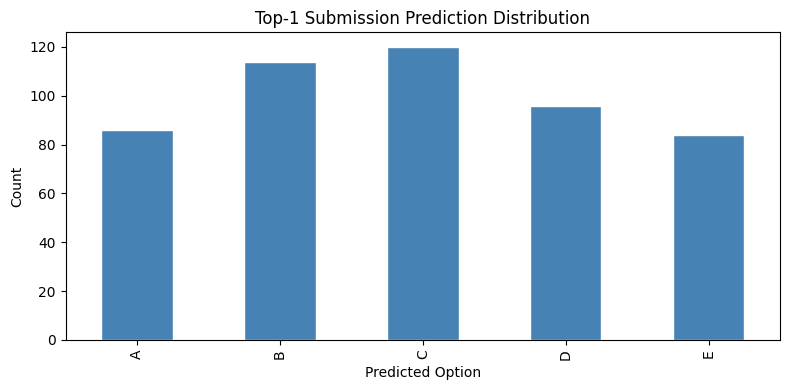


Final Summary:
  Hard lookup overrides : 500 (100.0%)
  Soft lookup boosts    : 0
  Model-only decisions  : 0
  BM25 Train MAP@3      : 0.3704
  RoBERTa CV MAP@3      : 0.9154
  ALBERT Val MAP@3      : 0.9912


In [22]:
import os

if not os.path.exists('submission.csv'):
    print('submission.csv not found — check the verification step above.')
else:
    sub_df = pd.read_csv('submission.csv')
    top1   = sub_df['Prediction'].str.split().str[0]

    print('Top-1 prediction distribution:')
    print(top1.value_counts().sort_index())
    print('(This should roughly mirror the training label distribution if the pipeline is healthy)')

    plt.figure(figsize=(8, 4))
    top1.value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
    plt.title('Top-1 Submission Prediction Distribution')
    plt.xlabel('Predicted Option')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    print('\nFinal Summary:')
    print(f'  Hard lookup overrides : {len(lookup_hard)} ({100*len(lookup_hard)/len(test_df):.1f}%)')
    print(f'  Soft lookup boosts    : {len(lookup_soft)}')
    print(f'  Model-only decisions  : {len(test_df) - len(lookup_hard)}')
    print(f'  BM25 Train MAP@3      : {m1_map3:.4f}')
    print(f'  RoBERTa CV MAP@3      : {np.mean(roberta_cv_scores):.4f}')
    print(f'  ALBERT Val MAP@3      : {best_albert_map3:.4f}')